<a href="https://colab.research.google.com/github/prnakyazze94/Data-608/blob/main/Minerals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Source Critical Mineral                         Primary Applications  \
0  MCS2024         Aluminum  Metallurgy and many sectors of the economy.   
1  MCS2024         Antimony    Flame retardants and lead-acid batteries.   
2  MCS2024          Arsenic               Pesticides and semiconductors.   
3  MCS2024           Barite                      Hydrocarbon production.   
4  MCS2024        Beryllium                       Aerospace and defense.   

  Category_Note  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4           NaN  
    Source  Import_Share_Order           Commodity  \
0  MCS2024                   1  ARSENIC, all forms   
1  MCS2024                   2            ASBESTOS   
2  MCS2024                   3              CESIUM   
3  MCS2024                   4           FLUORSPAR   
4  MCS2024                   5             GALLIUM   

   Net_Import_Reliance_pct_2023        Major_Import_Sources_2019_2022  \
0                           100     C

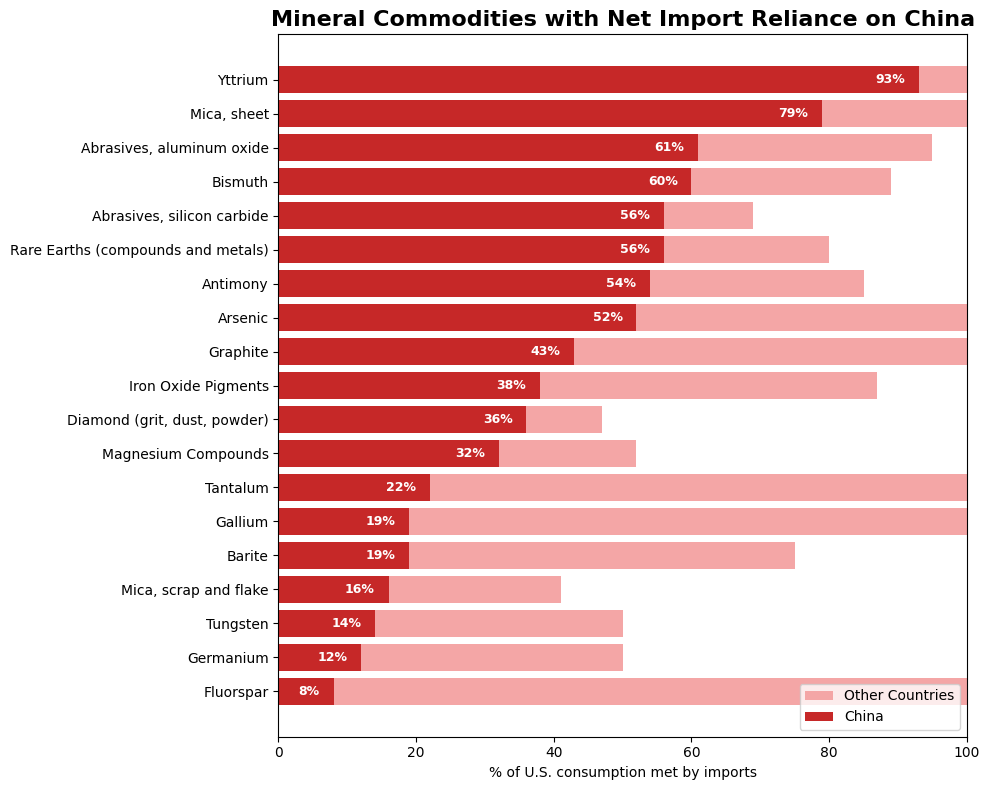

In [1]:
from datetime import MINYEAR
# =========================================================
# Critical Minerals Analysis — Python Version
# =========================================================

# Install if needed:
# pip install pandas matplotlib seaborn plotly squarify

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import re
import textwrap
import numpy as np
from matplotlib.lines import Line2D


# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------

end_use_data = pd.read_csv(
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Critical_minerals"
)

reliance_data = pd.read_csv(
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Import_Reliance"
)

source_data = pd.read_csv(
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Import_sources"
)

domestic_production_gap = pd.read_csv(
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Critical_minerals_saliency"
)

ch_mineral_data = pd.read_csv(
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Mineral_reliance_china"
)

min_class_data = pd.read_csv("https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Mineral_ctry_class"
)
mineral_gov = pd.read_csv("https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Mineral_governance_ind"
)
# ---------------------------------------------------------
# PREVIEW DATA
# ---------------------------------------------------------

print(end_use_data.head())
print(reliance_data.head())
print(source_data.head())
print(domestic_production_gap.head())
print(ch_mineral_data.head())
print(min_class_data.head())
print(mineral_gov.head())

# =========================================================
# 1. CHINA IMPORT RELIANCE CHART
# =========================================================

df = ch_mineral_data.copy()

# Sort for plotting
df = df.sort_values("From_China", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Light red background bars
ax.barh(
    df["Mineral"],
    df["Total_import_reliance"],
    color="#f4a6a6",
    label="Other Countries"
)

# Dark red overlay bars
ax.barh(
    df["Mineral"],
    df["From_China"],
    color="#c62828",
    label="China"
)

# Add labels
for i, value in enumerate(df["From_China"]):
    ax.text(
        value - 2,
        i,
        f"{value}%",
        va='center',
        ha='right',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xlim(0, 100)

ax.set_title(
    "Mineral Commodities with Net Import Reliance on China",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("% of U.S. consumption met by imports")
ax.set_ylabel("")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()










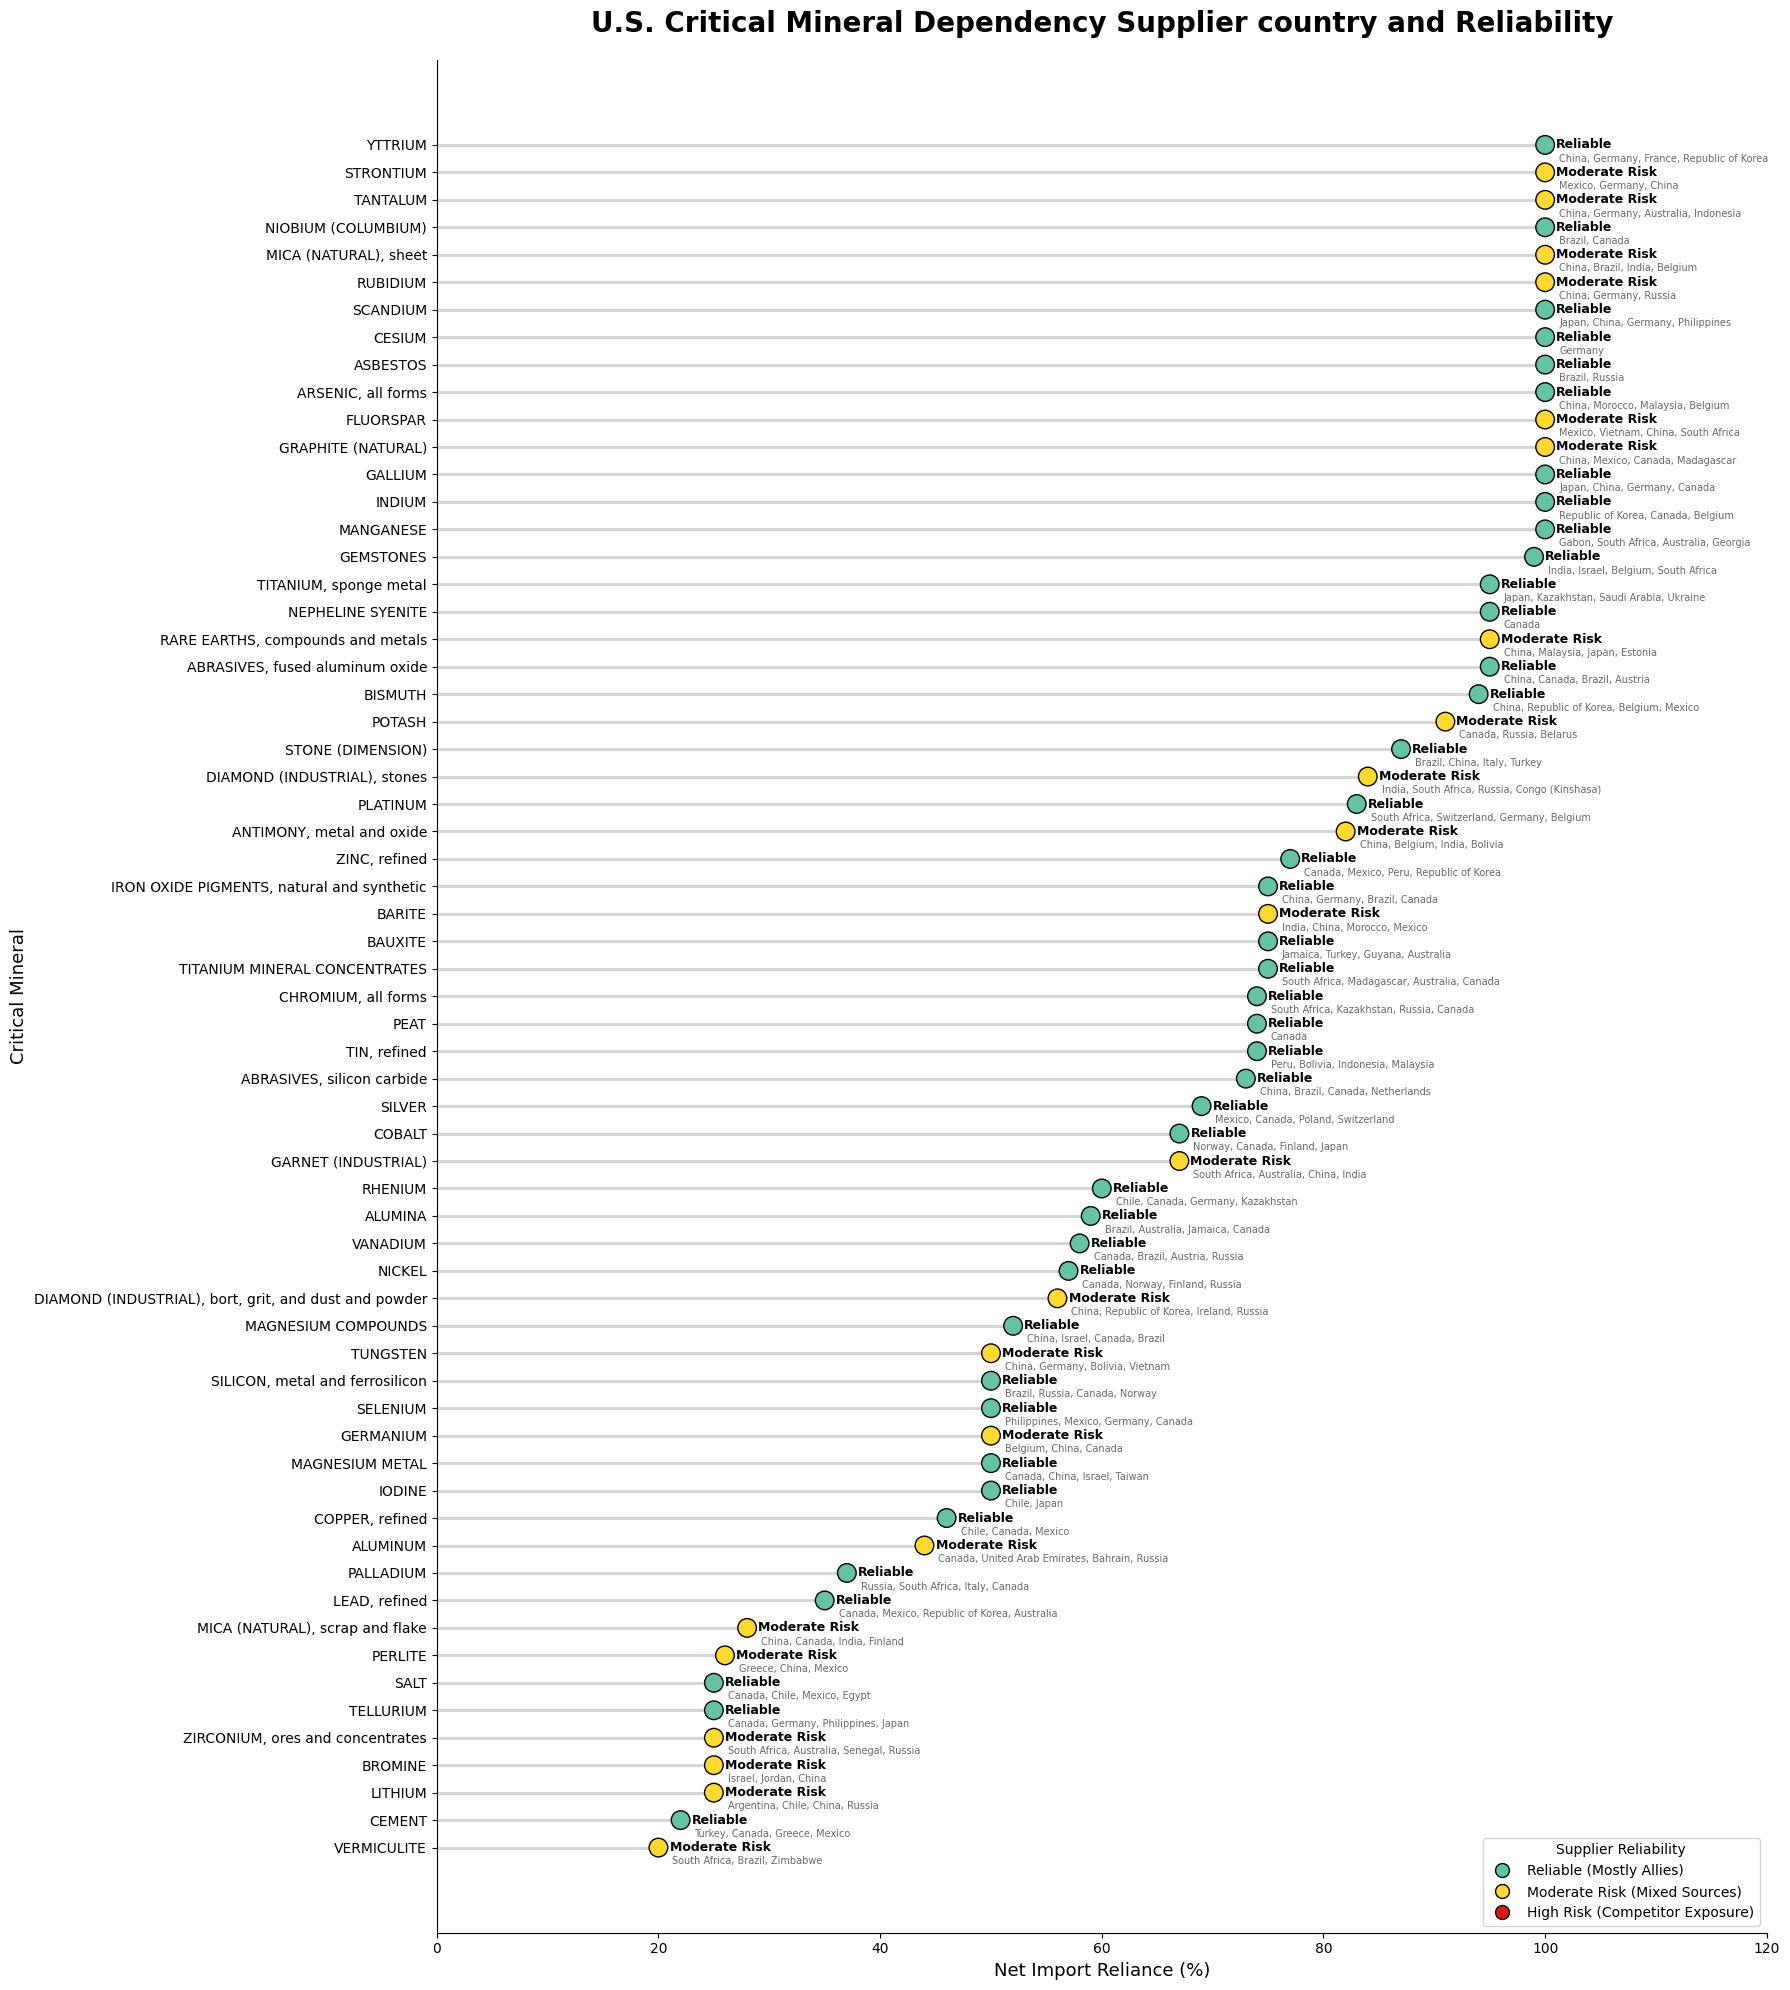

In [2]:


# =========================================================
# 1. CLEAN COUNTRY CLASSIFICATION DATA
# =========================================================

min_class_data["Country"] = min_class_data["Country"].replace({
    "South Korea": "Republic of Korea",
    "Russia": "Russian Federation"
})

# =========================================================
# 2. EXPAND IMPORT SOURCES
# =========================================================

expanded = reliance_data.copy()

expanded["Major_Import_Sources_2019_2022"] = (
    expanded["Major_Import_Sources_2019_2022"]
    .str.split(",")
)

expanded = expanded.explode(
    "Major_Import_Sources_2019_2022"
)

expanded["Major_Import_Sources_2019_2022"] = (
    expanded["Major_Import_Sources_2019_2022"]
    .str.strip()
)

# =========================================================
# 3. JOIN COUNTRY CLASSIFICATION
# =========================================================

expanded = expanded.merge(
    min_class_data,
    left_on="Major_Import_Sources_2019_2022",
    right_on="Country",
    how="left"
)

expanded["Classification"] = (
    expanded["Classification"]
    .fillna("Neutral")
)

# =========================================================
# 4. RELIABILITY SCORING
# =========================================================

reliability_scores = {
    "Ally": 3,
    "Neutral": 2,
    "Competitor": 1,
    "Unknown": 1
}

expanded["Reliability_Score"] = (
    expanded["Classification"]
    .map(reliability_scores)
)

# =========================================================
# 5. CREATE SUMMARY TABLE
# =========================================================

summary = (
    expanded.groupby("Commodity")
    .agg({
        "Reliability_Score": "mean",
        "Net_Import_Reliance_pct_2023": "first",
        "Major_Import_Sources_2019_2022":
            lambda x: ", ".join(x.unique())
    })
    .reset_index()
)

# =========================================================
# 6. CREATE RISK LABELS
# =========================================================

def reliability_label(score):
    if score >= 2.5:
        return "Reliable"
    elif score >= 1.75:
        return "Moderate Risk"
    else:
        return "High Risk"

summary["Risk_Level"] = (
    summary["Reliability_Score"]
    .apply(reliability_label)
)

# =========================================================
# 7. SORT DATA
# =========================================================

summary = summary.sort_values(
    "Net_Import_Reliance_pct_2023"
)

# =========================================================
# 8. COLORS
# =========================================================

risk_colors = {
    "Reliable": "#66c2a5",
    "Moderate Risk": "#ffd92f",
    "High Risk": "#d7191c"
}

colors = summary["Risk_Level"].map(risk_colors)

# =========================================================
# 9. CREATE PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(18, 20))

# Gray horizontal reference lines
ax.hlines(
    y=summary["Commodity"],
    xmin=0,
    xmax=summary["Net_Import_Reliance_pct_2023"],
    color="lightgray",
    linewidth=2
)

# Scatter points
ax.scatter(
    summary["Net_Import_Reliance_pct_2023"],
    summary["Commodity"],
    c=colors,
    s=180,
    edgecolor="black",
    zorder=3
)

# =========================================================
# 10. ADD SOURCE LABELS
# =========================================================

for _, row in summary.iterrows():

    # Main risk label
    ax.text(
        row["Net_Import_Reliance_pct_2023"] + 1,
        row["Commodity"],
        row["Risk_Level"],
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    # Supplier countries below mineral name
    ax.annotate(
        row["Major_Import_Sources_2019_2022"],
        (
            row["Net_Import_Reliance_pct_2023"],
            row["Commodity"]
        ),
        xytext=(10, -12),
        textcoords="offset points",
        fontsize=7,
        color="dimgray"
    )

# =========================================================
# 11. FORMATTING
# =========================================================

ax.set_title(
    "U.S. Critical Mineral Dependency Supplier country and Reliability",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Net Import Reliance (%)",
    fontsize=13
)

ax.set_ylabel(
    "Critical Mineral",
    fontsize=13
)

ax.set_xlim(0, 120)

# Remove clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# 12. LEGEND
# =========================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Reliable (Mostly Allies)',
        markerfacecolor='#66c2a5',
        markeredgecolor='black',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Moderate Risk (Mixed Sources)',
        markerfacecolor='#ffd92f',
        markeredgecolor='black',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='High Risk (Competitor Exposure)',
        markerfacecolor='#d7191c',
        markeredgecolor='black',
        markersize=10
    )
]

ax.legend(
    handles=legend_elements,
    title="Supplier Reliability",
    loc="lower right"
)

# =========================================================
# 13. FINAL LAYOUT
# =========================================================

plt.tight_layout()
plt.show()

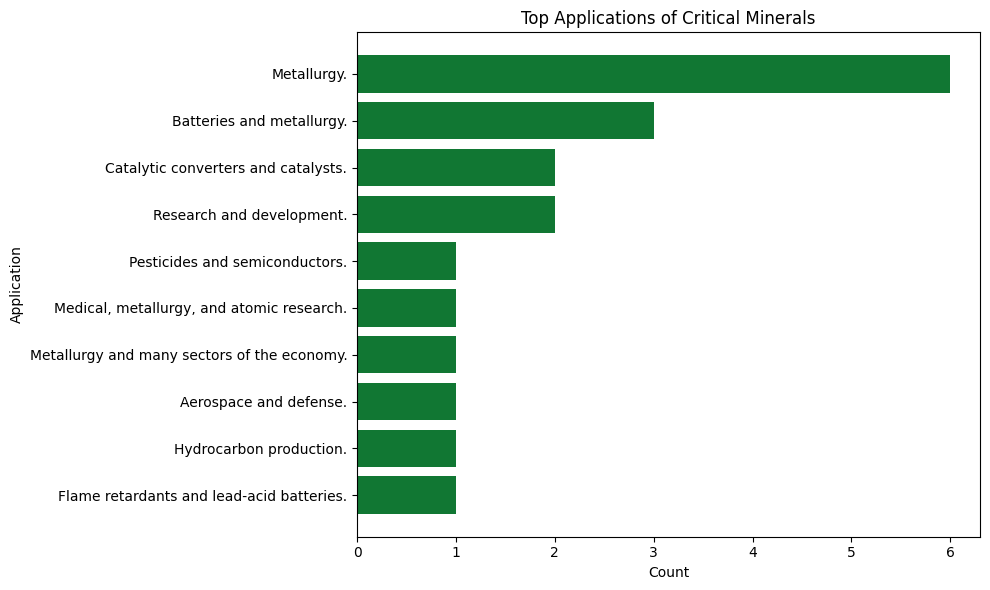

In [3]:
# =========================================================
# 2. TOP APPLICATIONS OF CRITICAL MINERALS
# =========================================================

top_apps = (
    end_use_data["Primary Applications"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_apps.index,
    top_apps.values,
    color="#117733"
)

ax.set_title("Top Applications of Critical Minerals")
ax.set_xlabel("Count")
ax.set_ylabel("Application")

plt.tight_layout()
plt.show()



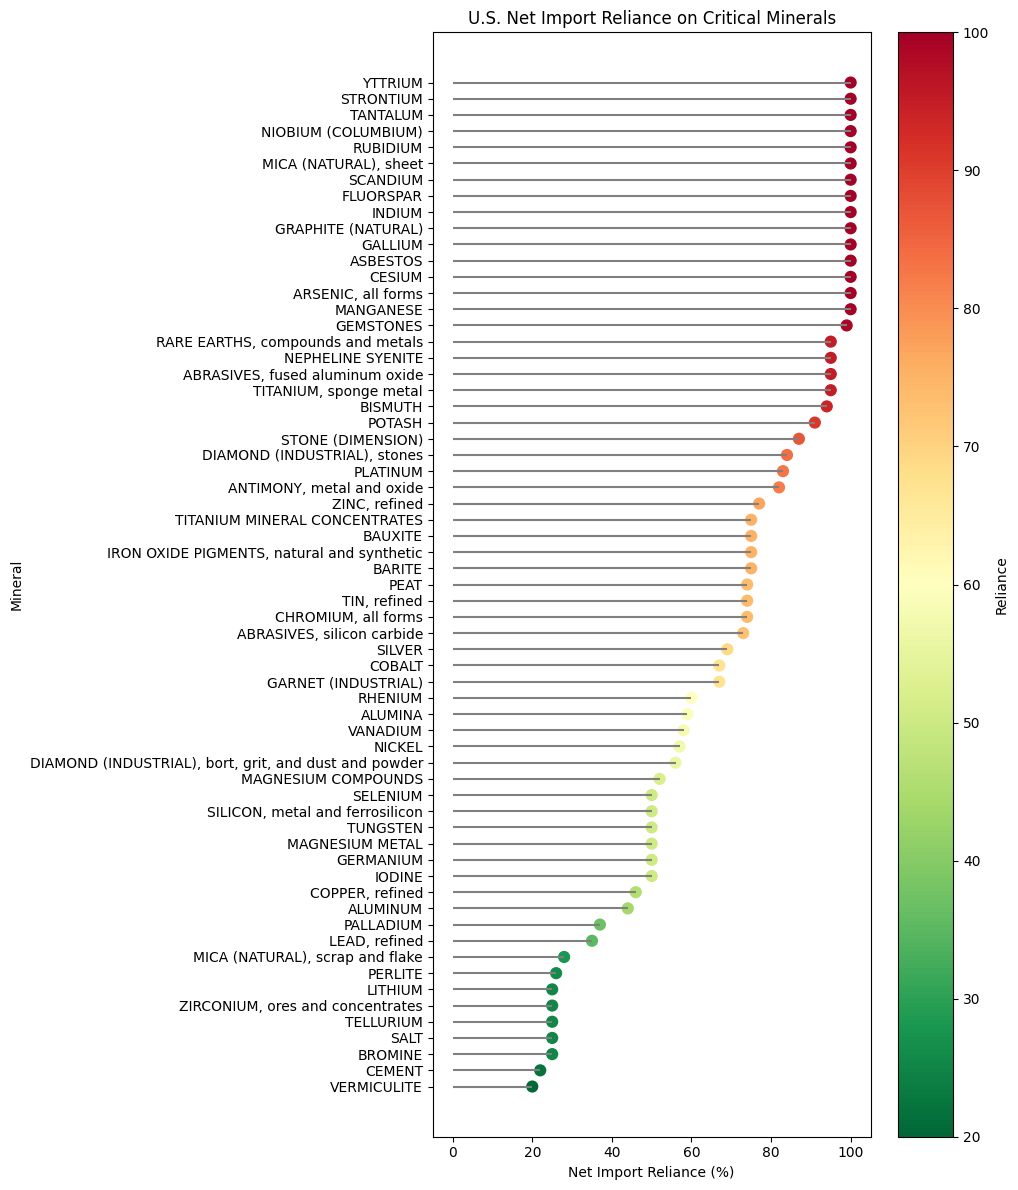

In [ ]:


# =========================================================
# 3. NET IMPORT RELIANCE DOT PLOT
# =========================================================

reliance_sorted = reliance_data.sort_values(
    "Net_Import_Reliance_pct_2023"
)

fig, ax = plt.subplots(figsize=(10, 12))

ax.hlines(
    y=reliance_sorted["Commodity"],
    xmin=0,
    xmax=reliance_sorted["Net_Import_Reliance_pct_2023"],
    color="gray"
)

scatter = ax.scatter(
    reliance_sorted["Net_Import_Reliance_pct_2023"],
    reliance_sorted["Commodity"],
    c=reliance_sorted["Net_Import_Reliance_pct_2023"],
    cmap="RdYlGn_r",
    s=60
)

plt.colorbar(scatter, label="Reliance")

ax.set_title("U.S. Net Import Reliance on Critical Minerals")
ax.set_xlabel("Net Import Reliance (%)")
ax.set_ylabel("Mineral")

plt.tight_layout()
plt.show()






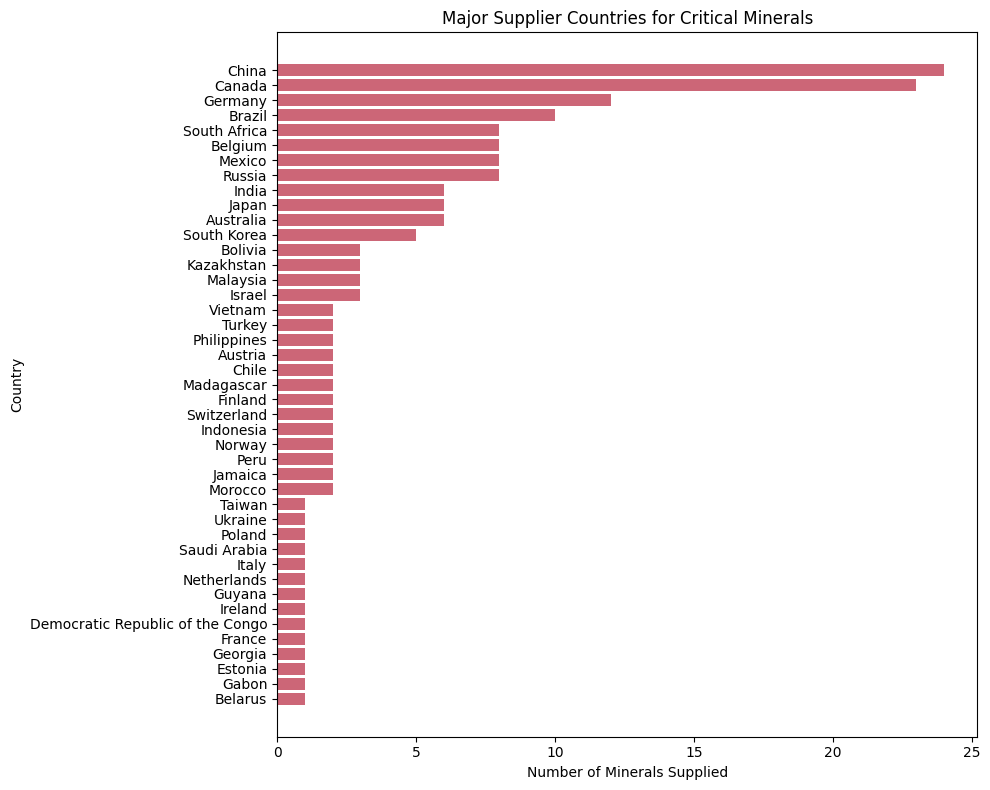

In [ ]:
# =========================================================
# 4. MAJOR SUPPLIER COUNTRIES
# =========================================================

country_df = source_data.sort_values(
    "Commodity_Count",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    country_df["Country"],
    country_df["Commodity_Count"],
    color="#CC6677"
)

ax.set_title("Major Supplier Countries for Critical Minerals")
ax.set_xlabel("Number of Minerals Supplied")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()



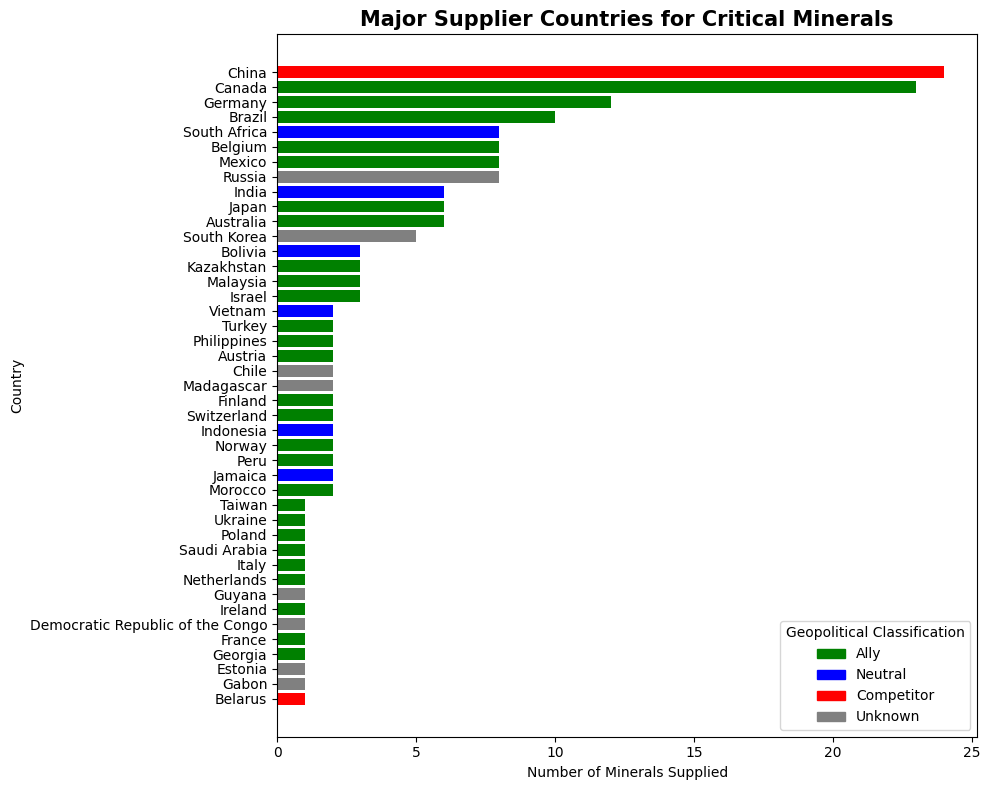

In [4]:
# =========================================================
# 4. MAJOR SUPPLIER COUNTRIES
# WITH GEOPOLITICAL CLASSIFICATION COLORS
# =========================================================
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# JOIN CLASSIFICATION TO SOURCE DATA
# ---------------------------------------------------------
country_df = (
    source_data
    .merge(min_class_data, on="Country", how="left")
    .sort_values("Commodity_Count", ascending=True)
)

# Fill missing classifications
country_df["Classification"] = country_df["Classification"].fillna("Unknown")

# ---------------------------------------------------------
# COLOR MAP (Using your requested green and blue)
# ---------------------------------------------------------
color_map = {
    "Ally": "green",
    "Neutral": "blue",
    "Competitor": "red",
    "Unknown": "gray"
}

# FIX: Define bar_colors based on the merged dataframe
bar_colors = [color_map.get(cls, "gray") for cls in country_df["Classification"]]

# Create legend handles
legend_handles = [
    mpatches.Patch(color=color_map[label], label=label)
    for label in ["Ally", "Neutral", "Competitor", "Unknown"]
]

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Use the newly defined bar_colors
ax.barh(
    country_df["Country"],
    country_df["Commodity_Count"],
    color=bar_colors
)

ax.legend(
    handles=legend_handles,
    title="Geopolitical Classification",
    loc="lower right",
    frameon=True
)

ax.set_title("Major Supplier Countries for Critical Minerals", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of Minerals Supplied")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

    Source Critical Mineral                         Primary Applications  \
0  MCS2024         Aluminum  Metallurgy and many sectors of the economy.   
1  MCS2024         Antimony    Flame retardants and lead-acid batteries.   
2  MCS2024          Arsenic               Pesticides and semiconductors.   
3  MCS2024           Barite                      Hydrocarbon production.   
4  MCS2024        Beryllium                       Aerospace and defense.   

  Category_Note  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4           NaN  
    Source  Import_Share_Order           Commodity  \
0  MCS2024                   1  ARSENIC, all forms   
1  MCS2024                   2            ASBESTOS   
2  MCS2024                   3              CESIUM   
3  MCS2024                   4           FLUORSPAR   
4  MCS2024                   5             GALLIUM   

   Net_Import_Reliance_pct_2023        Major_Import_Sources_2019_2022  \
0                           100     C

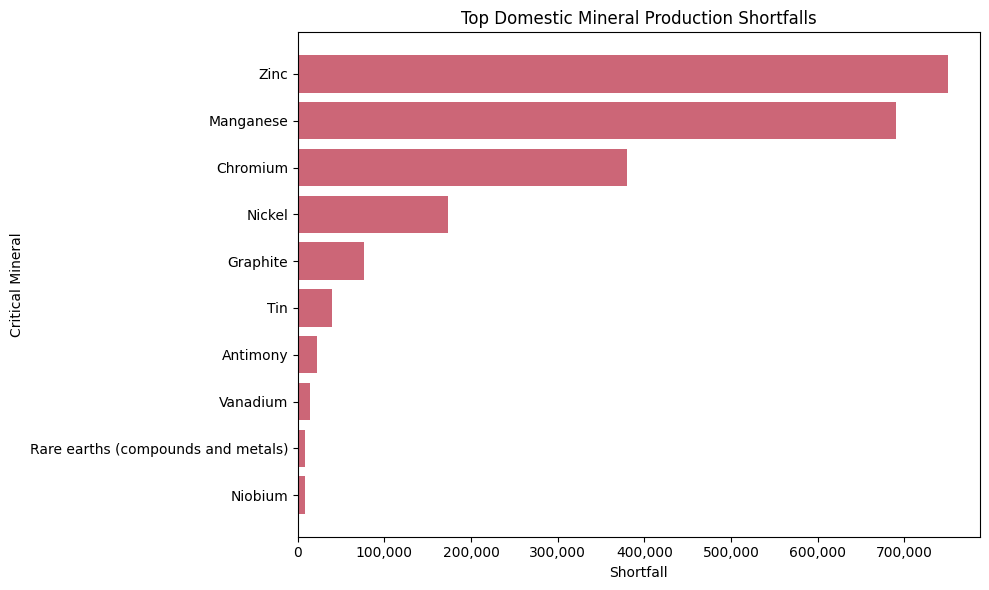

In [ ]:
print(end_use_data.head())
print(reliance_data.head())
print(source_data.head())
print(domestic_production_gap.head())
print(ch_mineral_data.head())


# =========================================================
# 5. DOMESTIC PRODUCTION SHORTFALLS
# =========================================================

# Clean numeric columns
domestic_production_gap["Primary_prod"] = (
    domestic_production_gap["Primary_prod"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)

domestic_production_gap["Apparent_Consuption"] = (
    domestic_production_gap["Apparent_Consuption"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)

domestic_production_gap["Primary_prod"] = pd.to_numeric(
    domestic_production_gap["Primary_prod"],
    errors="coerce"
)

domestic_production_gap["Apparent_Consuption"] = pd.to_numeric(
    domestic_production_gap["Apparent_Consuption"],
    errors="coerce"
)

# Compute shortfall
domestic_production_gap["shortfall"] = (
    domestic_production_gap["Apparent_Consuption"]
    - domestic_production_gap["Primary_prod"]
)

shortfall_df = (
    domestic_production_gap
    .dropna(subset=["shortfall"])
    .sort_values("shortfall", ascending=False)
    .head(10)
    .sort_values("shortfall")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    shortfall_df["Critical_mineral"],
    shortfall_df["shortfall"],
    color="#CC6677"
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax.set_title("Top Domestic Mineral Production Shortfalls")
ax.set_xlabel("Shortfall")
ax.set_ylabel("Critical Mineral")

plt.tight_layout()
plt.show()



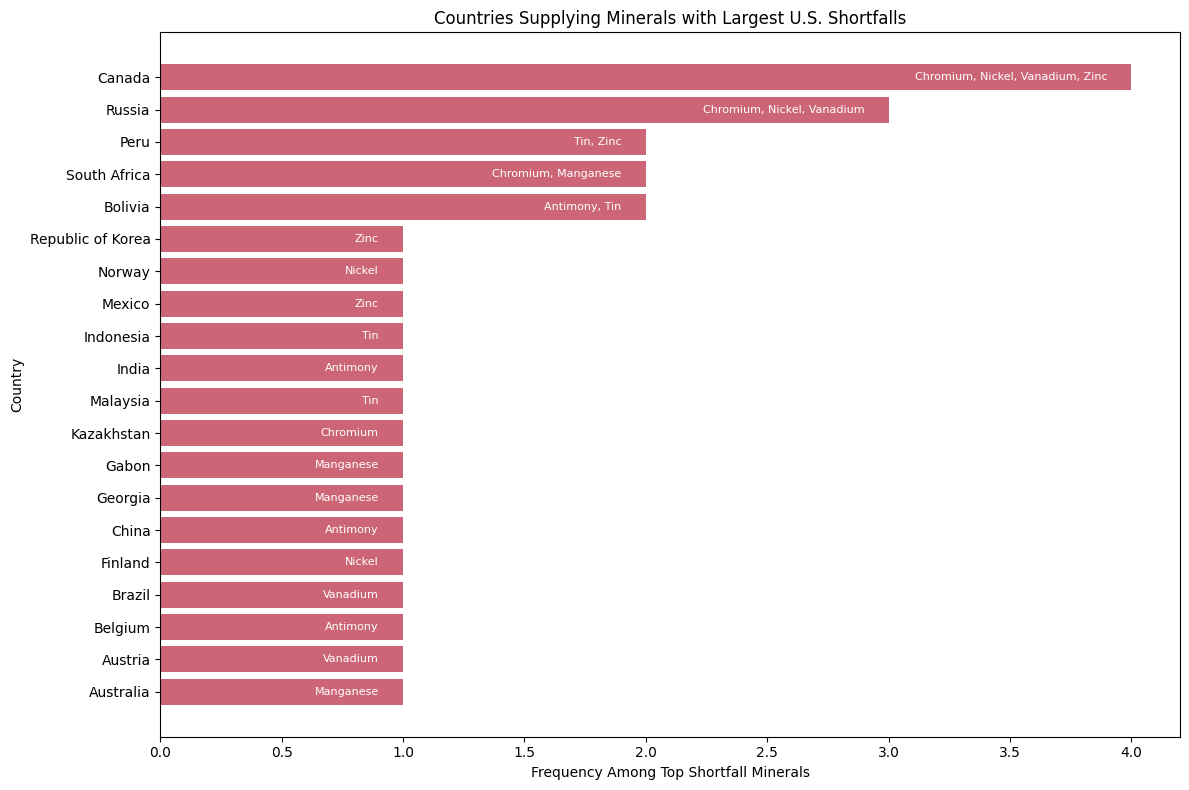

In [ ]:
# =========================================================
# 6. COUNTRIES SUPPLYING TOP SHORTFALL MINERALS
# =========================================================

# Top minerals
top_shortfall = (
    domestic_production_gap
    .sort_values("shortfall", ascending=False)
    .head(10)
)

top_shortfall["mineral_clean"] = (
    top_shortfall["Critical_mineral"]
    .str.upper()
    .str.strip()
)

# Clean reliance names
reliance_data["mineral_clean"] = (
    reliance_data["Commodity"]
    .str.replace(r",.*", "", regex=True)
    .str.upper()
    .str.strip()
)

# Merge
matched = pd.merge(
    reliance_data,
    top_shortfall,
    on="mineral_clean"
)

# Split countries
country_rows = []

for _, row in matched.iterrows():

    countries = str(
        row["Major_Import_Sources_2019_2022"]
    ).split(",")

    for country in countries:

        country_rows.append({
            "Country": country.strip(),
            "mineral": row["Critical_mineral"]
        })

country_data = pd.DataFrame(country_rows)

# Summarize
country_summary = (
    country_data
    .groupby("Country")
    .agg(
        n=("mineral", "count"),
        minerals_list=("mineral",
                       lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
    .sort_values("n", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    country_summary["Country"],
    country_summary["n"],
    color="#CC6677"
)

# Add labels inside bars
for bar, label in zip(
    bars,
    country_summary["minerals_list"]
):
    ax.text(
        bar.get_width() - 0.1,
        bar.get_y() + bar.get_height()/2,
        label,
        ha='right',
        va='center',
        color='white',
        fontsize=8
    )

ax.set_title(
    "Countries Supplying Minerals with Largest U.S. Shortfalls"
)

ax.set_xlabel(
    "Frequency Among Top Shortfall Minerals"
)

ax.set_ylabel("Country")

plt.tight_layout()
plt.show()




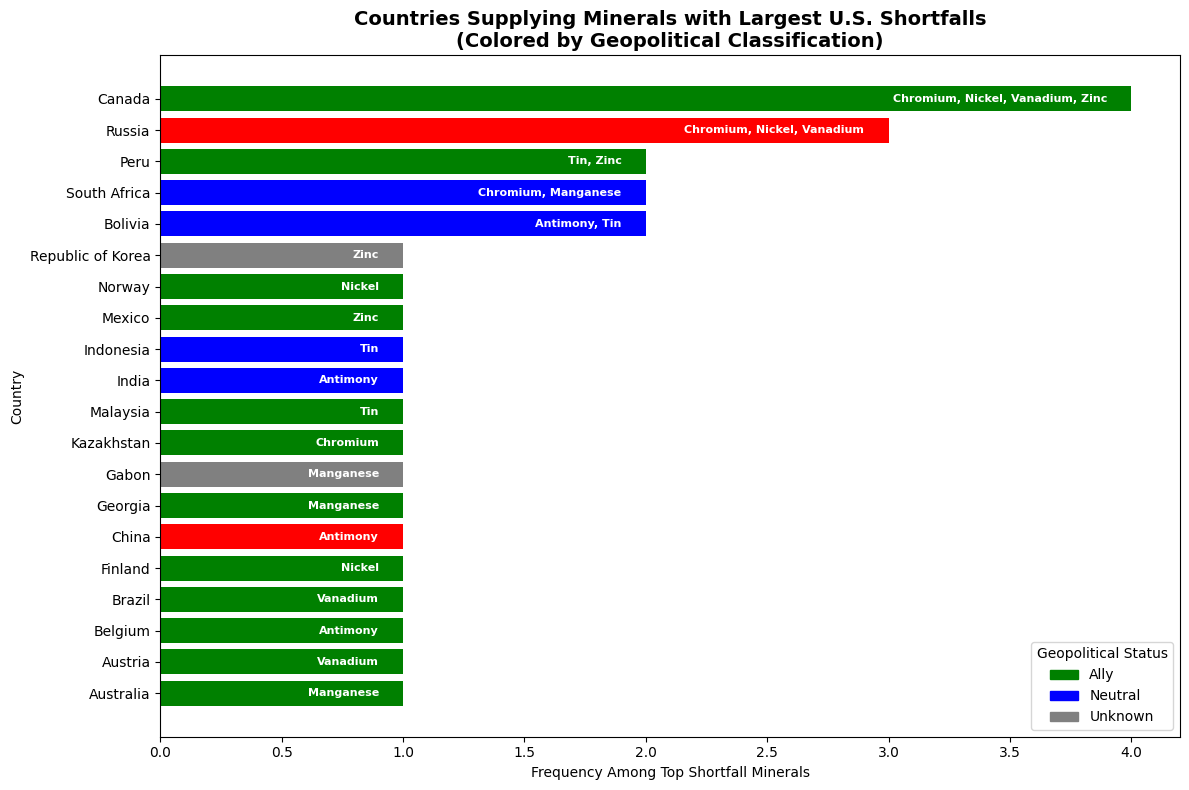

In [ ]:
# 1. Merge and IMMEDIATELY handle missing values
country_summary_classed = country_summary.merge(
    min_class_data,
    on="Country",
    how="left"
)

# Replace any NaN classifications with "Unknown"
country_summary_classed["Classification"] = country_summary_classed["Classification"].fillna("Unknown")

# 2. Define the color map (Ensure it covers all possible labels)
color_map = {
    "Ally": "green",
    "Neutral": "blue",
    "Unknown": "gray",
    "Competitor": "red" # Adding this just in case
}

# 3. Create the bar_colors list
# Using .get() provides a fallback color if a label isn't in the map
bar_colors = [color_map.get(cls, "gray") for cls in country_summary_classed["Classification"]]

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    country_summary_classed["Country"],
    country_summary_classed["n"],
    color=bar_colors
)

# ... (rest of your labeling and legend code)

# Add labels inside bars
for bar, label in zip(bars, country_summary_classed["minerals_list"]):
    ax.text(
        bar.get_width() - 0.1,
        bar.get_y() + bar.get_height()/2,
        label,
        ha='right',
        va='center',
        color='white',
        fontsize=8,
        fontweight='bold'
    )

# 4. Add a legend for the classifications
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='green', label='Ally'),
    mpatches.Patch(color='blue', label='Neutral'),
    mpatches.Patch(color='gray', label='Unknown')
]
ax.legend(handles=legend_handles, title="Geopolitical Status", loc="lower right")

ax.set_title("Countries Supplying Minerals with Largest U.S. Shortfalls\n(Colored by Geopolitical Classification)", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency Among Top Shortfall Minerals")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

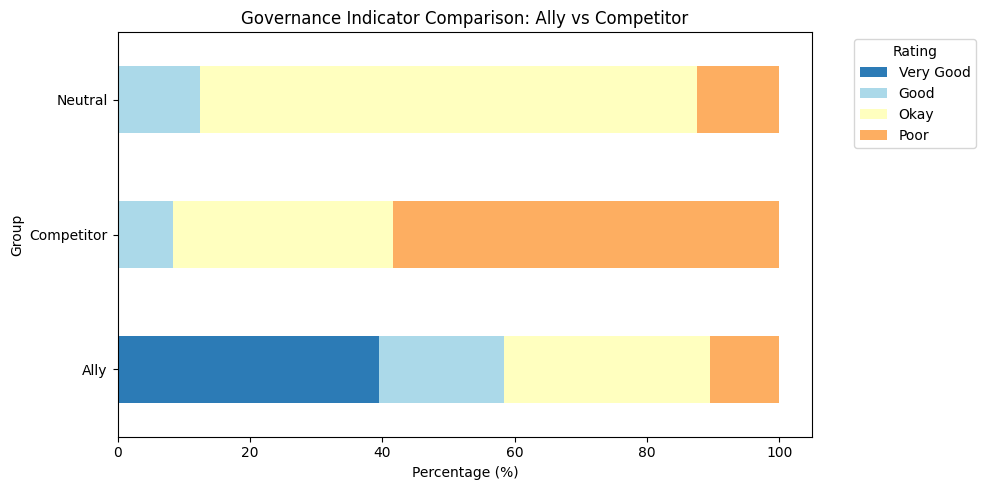

In [ ]:


# 1. Join the existing DataFrames
df = pd.merge(mineral_gov, min_class_data, left_on='economy', right_on='Country')

# 2. Define the Governance Rating bins (as per World Bank/RPubs style)
def get_rating(score):
    if score >= 80: return 'Very Good'
    elif score >= 60: return 'Good'
    elif score >= 40: return 'Okay'
    elif score >= 20: return 'Poor'
    else: return 'Very Poor'

df['Rating'] = df['governance_score'].apply(get_rating)

# 3. Pivot the data to get percentages for the stacked bars
# This calculates what % of each group (Ally vs Competitor) falls into each Rating
summary = df.groupby(['Classification', 'Rating']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# 4. Ensure the ratings are in the correct logical order for the legend
order = ['Very Good', 'Good', 'Okay', 'Poor', 'Very Poor']
summary_pct = summary_pct.reindex(columns=[c for c in order if c in summary_pct.columns])

# 5. Plotting
# Color hex codes similar to the RPubs visualization
colors = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']

ax = summary_pct.plot(kind='barh',
                      stacked=True,
                      color=colors[:len(summary_pct.columns)],
                      figsize=(10, 5))

# Formatting the chart
plt.title('Governance Indicator Comparison: Ally vs Competitor')
plt.xlabel('Percentage (%)')
plt.ylabel('Group')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

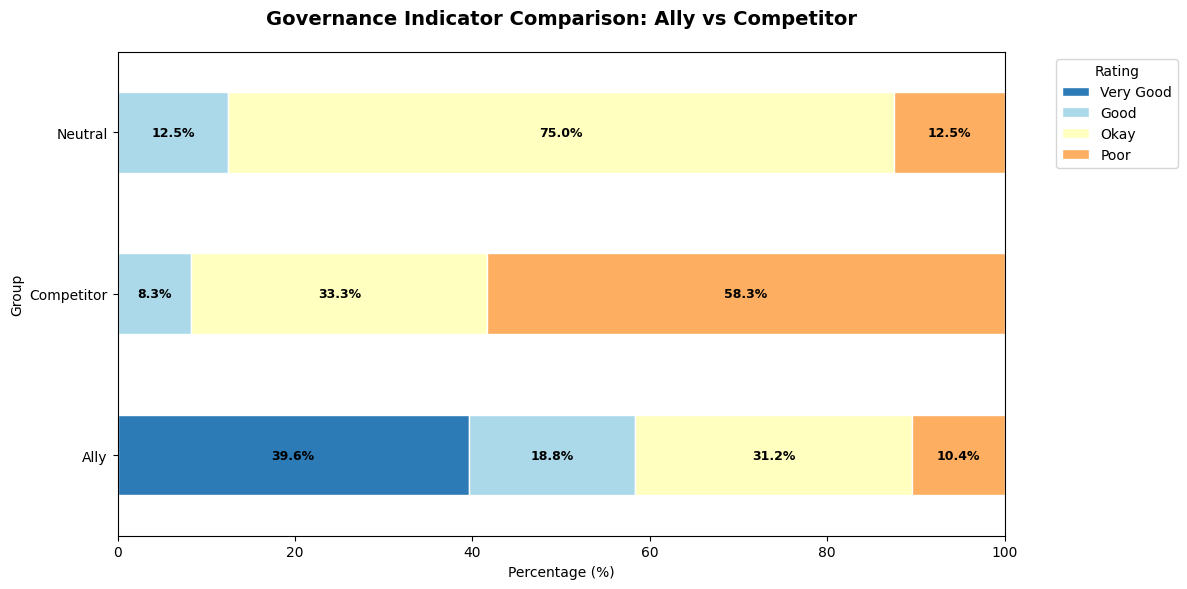

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Join the existing DataFrames
df = pd.merge(mineral_gov, min_class_data, left_on='economy', right_on='Country')

# 2. Define the Governance Rating bins
def get_rating(score):
    if score >= 80: return 'Very Good'
    elif score >= 60: return 'Good'
    elif score >= 40: return 'Okay'
    elif score >= 20: return 'Poor'
    else: return 'Very Poor'

df['Rating'] = df['governance_score'].apply(get_rating)

# 3. Pivot the data to get percentages
summary = df.groupby(['Classification', 'Rating']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# 4. Ensure logical order
order = ['Very Good', 'Good', 'Okay', 'Poor', 'Very Poor']
summary_pct = summary_pct.reindex(columns=[c for c in order if c in summary_pct.columns])

# 5. Plotting
colors = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']

ax = summary_pct.plot(kind='barh',
                      stacked=True,
                      color=colors[:len(summary_pct.columns)],
                      figsize=(12, 6),
                      edgecolor='white')

# ---------------------------------------------------------
# NEW: ADD LABELS INSIDE THE BARS
# ---------------------------------------------------------
for p in ax.patches:
    width = p.get_width()
    if width > 0:  # Only label segments that have a value
        # Calculate the center of the segment
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2

        ax.annotate(f'{width:.1f}%',
                    (x, y),
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold',
                    color='black')

# Formatting the chart
plt.title('Governance Indicator Comparison: Ally vs Competitor', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Percentage (%)')
plt.ylabel('Group')
plt.xlim(0, 100) # Ensure the scale stays at 100%
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

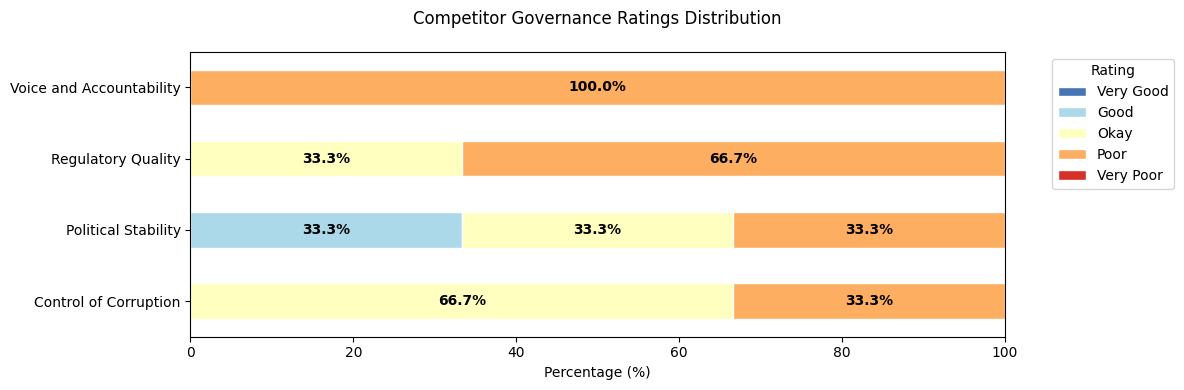

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Join the existing dataframes
df = pd.merge(mineral_gov, min_class_data, left_on='economy', right_on='Country')

# 2. Filter specifically for Competitors
comp_df = df[df['Classification'] == 'Competitor'].copy()

# 3. Categorize the governance_score into Ratings
def get_rating(score):
    if score >= 80: return 'Very Good'
    elif score >= 60: return 'Good'
    elif score >= 40: return 'Okay'
    elif score >= 20: return 'Poor'
    else: return 'Very Poor'

comp_df['Rating'] = comp_df['governance_score'].apply(get_rating)

# 4. Calculate percentage distribution per Indicator
summary = comp_df.groupby(['Indicator', 'Rating']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# Ensure all standard categories are present and in order
all_ratings = ['Very Good', 'Good', 'Okay', 'Poor', 'Very Poor']
for rating in all_ratings:
    if rating not in summary_pct.columns:
        summary_pct[rating] = 0.0
summary_pct = summary_pct[all_ratings]

# 5. Define the color palette (matches the World Bank/RPubs style)
colors = ['#4575b4', '#abd9e9', '#ffffbf', '#fdae61', '#d73027']

# 6. Plotting
fig, ax = plt.subplots(figsize=(12, 4))
summary_pct.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='white')

# 7. Add percentage labels inside the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        # Calculate text position (center of the segment)
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{width:.1f}%', (x, y), ha='center', va='center',
                    fontsize=10, fontweight='bold', color='black')

# Chart Formatting
plt.title('Competitor Governance Ratings Distribution', loc='center', pad=20)
plt.xlabel('Percentage (%)')
plt.ylabel('')
plt.xlim(0, 100)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

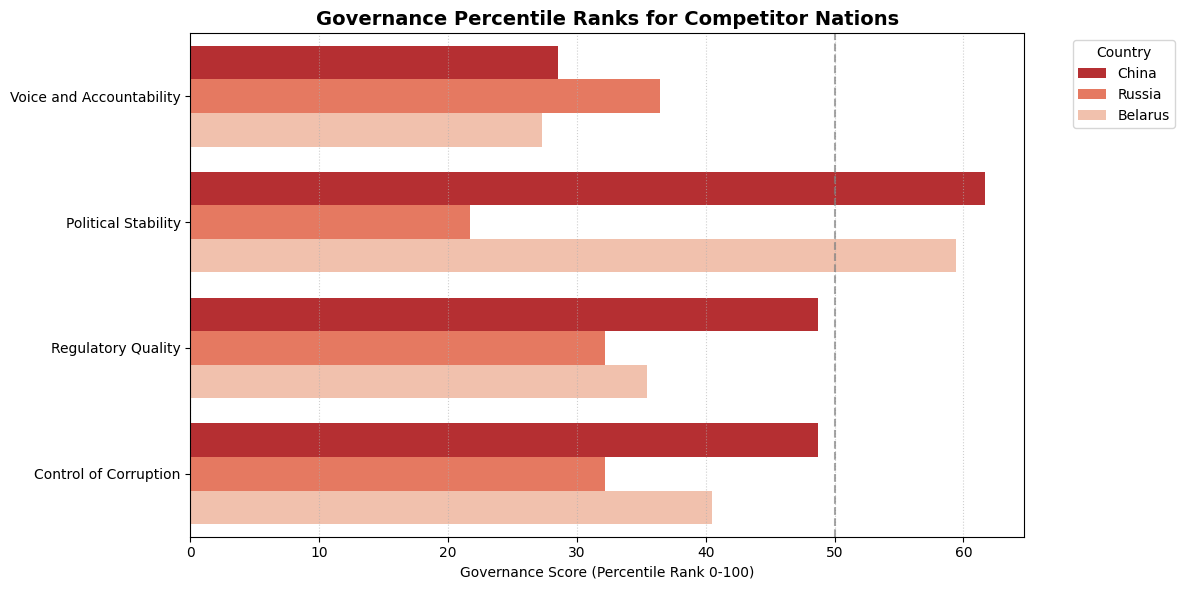

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge the governance data with classifications
df_gov = pd.merge(mineral_gov, min_class_data, left_on='economy', right_on='Country')

# 2. Filter for 'Competitor' countries to see their specific percentages
comp_scores = df_gov[df_gov['Classification'] == 'Competitor'].copy()

# 3. Plot the actual governance scores (percentages)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comp_scores,
    x='governance_score',
    y='Indicator',
    hue='economy',
    palette='Reds_r'
)

# Add a vertical line at 50% for context
plt.axvline(50, color='gray', linestyle='--', alpha=0.7)

plt.title('Governance Percentile Ranks for Competitor Nations', fontsize=14, fontweight='bold')
plt.xlabel('Governance Score (Percentile Rank 0-100)')
plt.ylabel('')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

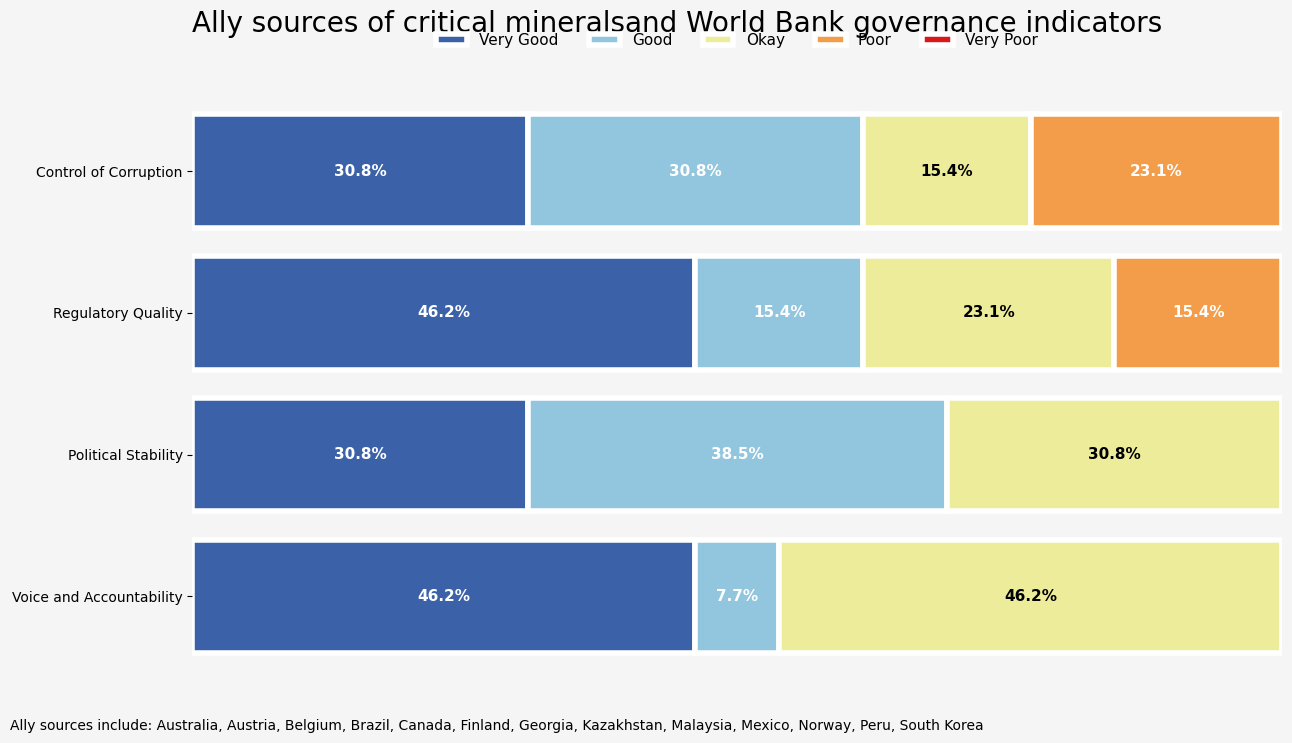

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. CLEAN COLUMN NAMES
# =========================================================

mineral_gov.columns = mineral_gov.columns.str.strip()
min_class_data.columns = min_class_data.columns.str.strip()

# =========================================================
# 2. STANDARDIZE COUNTRY NAMES
# =========================================================

country_fix = {
    "Russia": "Russia",
    "Korea": "South Korea"
}

mineral_gov["economy"] = (
    mineral_gov["economy"]
    .replace(country_fix)
)

# =========================================================
# 3. JOIN DATA
# =========================================================

df = pd.merge(
    mineral_gov,
    min_class_data,
    left_on="economy",
    right_on="Country",
    how="left"
)

# =========================================================
# 4. GOVERNANCE RATING FUNCTION
# =========================================================

def get_rating(score):

    if score >= 80:
        return "Very Good"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Okay"

    elif score >= 20:
        return "Poor"

    else:
        return "Very Poor"

df["Rating"] = (
    df["governance_score"]
    .apply(get_rating)
)

# =========================================================
# 5. KEEP TARGET INDICATORS
# =========================================================

target_indicators = [
    "Voice and Accountability",
    "Political Stability",
    "Regulatory Quality",
    "Control of Corruption"
]

df = df[
    df["Indicator"].isin(target_indicators)
]

# =========================================================
# 6. COLORS
# =========================================================

colors = {
    "Very Good": "#3b62a8",
    "Good": "#92c5de",
    "Okay": "#ecec9a",
    "Poor": "#f39c4a",
    "Very Poor": "#d7191c"
}

rating_order = [
    "Very Good",
    "Good",
    "Okay",
    "Poor",
    "Very Poor"
]

indicator_order = [
    "Control of Corruption",
    "Regulatory Quality",
    "Political Stability",
    "Voice and Accountability"
]

# =========================================================
# 7. FUNCTION TO CREATE RPUBS STYLE PLOT
# =========================================================

def create_governance_plot(group_name):

    # Filter group
    group_df = df[
        df["Classification"] == group_name
    ].copy()

    # Create percentages
    summary = (
        group_df
        .groupby(["Indicator", "Rating"])
        .size()
        .unstack(fill_value=0)
    )

    summary_pct = (
        summary
        .div(summary.sum(axis=1), axis=0)
        * 100
    )

    summary_pct = summary_pct.reindex(
        columns=rating_order
    )

    summary_pct = summary_pct.reindex(
        indicator_order
    )

    # -----------------------------------------------------
    # CREATE FIGURE
    # -----------------------------------------------------

    fig, ax = plt.subplots(figsize=(13, 7))

    left = np.zeros(len(summary_pct))

    # Create stacked bars
    for rating in rating_order:

        values = summary_pct[rating]

        bars = ax.barh(
            summary_pct.index,
            values,
            left=left,
            color=colors[rating],
            edgecolor="white",
            linewidth=4,
            label=rating
        )

        # Add labels
        for bar, value in zip(bars, values):

            if value >= 7:

                text_color = (
                    "black"
                    if rating == "Okay"
                    else "white"
                )

                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=11,
                    fontweight="bold",
                    color=text_color
                )

        left += values

    # -----------------------------------------------------
    # STYLE
    # -----------------------------------------------------

    ax.invert_yaxis()

    ax.set_xlim(0, 100)

    ax.set_xticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_title(
        f"{group_name} sources of critical minerals"
        f"and World Bank governance indicators",
        fontsize=20,
        loc="left",
        pad=40
    )

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Background
    fig.patch.set_facecolor("#f5f5f5")
    ax.set_facecolor("#f5f5f5")

    # Legend
    ax.legend(
        ncol=5,
        bbox_to_anchor=(0.5, 1.08),
        loc="center",
        frameon=False,
        fontsize=11
    )

    # -----------------------------------------------------
    # ADD COUNTRY LIST FOOTNOTE
    # -----------------------------------------------------

    countries = sorted(
        group_df["economy"]
        .dropna()
        .unique()
    )

    country_text = ", ".join(countries)

    plt.figtext(
        0.01,
        -0.05,
        f"{group_name} sources include: {country_text}",
        ha="left",
        fontsize=10
    )

    plt.tight_layout()

    plt.show()

# =========================================================
# 8. CREATE BOTH PLOTS
# =========================================================

create_governance_plot("Ally")



In [ ]:
# Check if "Competitor" exists in your merged data
print("Rows found for Competitor:", len(df[df["Classification"] == "Competitor"]))

# If 0, check your unique classifications
print("Current Classifications in data:", df["Classification"].unique())

Rows found for Competitor: 12
Current Classifications in data: ['Ally' 'Neutral' 'Competitor' nan]


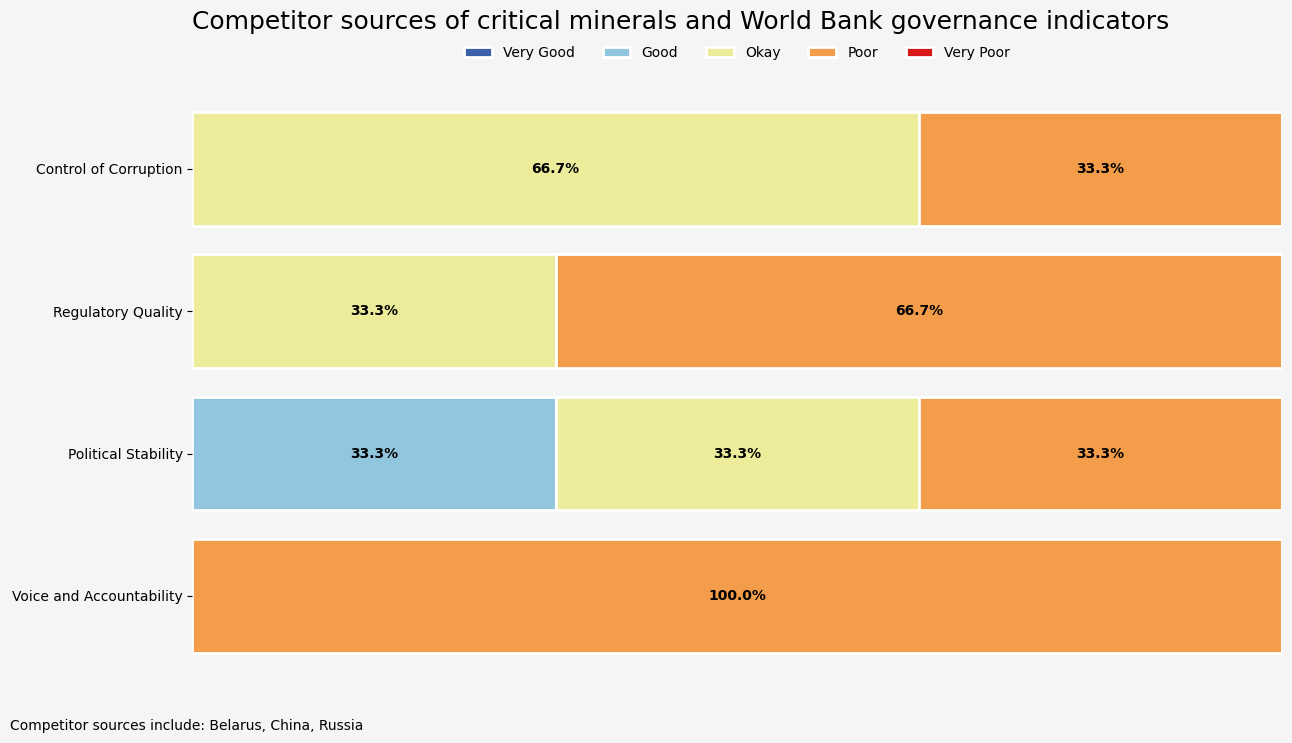

In [ ]:
def create_governance_plot(group_name):
    # 1. Filter group
    group_df = df[df["Classification"] == group_name].copy()

    # 2. Create percentages
    summary = (
        group_df
        .groupby(["Indicator", "Rating"])
        .size()
        .unstack(fill_value=0)
    )
    summary_pct = (
        summary
        .div(summary.sum(axis=1), axis=0)
        * 100
    )
    summary_pct = summary_pct.reindex(columns=rating_order).fillna(0)
    summary_pct = summary_pct.reindex(indicator_order)

    # 3. Create Figure
    fig, ax = plt.subplots(figsize=(13, 7))
    left = np.zeros(len(summary_pct))

    # 4. Create stacked bars and add labels
    for rating in rating_order:
        if rating in summary_pct.columns:
            values = summary_pct[rating]
            bars = ax.barh(
                summary_pct.index,
                values,
                left=left,
                color=colors[rating],
                edgecolor="white",
                linewidth=2,
                label=rating
            )

            # Add labels inside segments
            for bar, value in zip(bars, values):
                if value >= 5:  # Label if segment is at least 5%
                    # Use black text for better contrast on red/yellow bars
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{value:.1f}%",
                        ha="center",
                        va="center",
                        fontsize=10,
                        fontweight="bold",
                        color="black"
                    )
            left += values

    # 5. Styling
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xticks([])
    ax.set_title(
        f"{group_name} sources of critical minerals "
        f"and World Bank governance indicators",
        fontsize=18, loc="left", pad=40
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.patch.set_facecolor("#f5f5f5")
    ax.set_facecolor("#f5f5f5")

    ax.legend(ncol=5, bbox_to_anchor=(0.5, 1.02), loc="lower center", frameon=False)

    # 6. Country Footnote (Fixed Indentation)
    countries = sorted(group_df["economy"].dropna().unique())
    country_text = ", ".join(countries)
    plt.figtext(0.01, -0.05, f"{group_name} sources include: {country_text}",
                ha="left", fontsize=10, wrap=True)

    plt.tight_layout()
    plt.show()

# Run for Competitor
create_governance_plot("Competitor")